<a href="https://colab.research.google.com/github/fujisawatet/Spotify_data/blob/main/%E3%82%B8%E3%83%A3%E3%83%B3%E3%83%AB%E5%88%A5_2020_2021_SHAP%E3%82%AF%E3%83%A9%E3%82%B9%E3%82%BF%E3%83%AA%E3%83%B3%E3%82%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#7.21 必要なコードだけに整理

In [ ]:
#@title import
from urllib.request import urlretrieve
import os
from zipfile import ZipFile

import pandas as pd

In [ ]:
boxurl = "https://tus.box.com/shared/static/491ie3a5kdgg7hfajivmwlou6zq2fnzj.zip"
filename = "Kaggle_Spotify_1Million_Tracks.zip"

In [ ]:
%%time
urlretrieve(boxurl, filename)

CPU times: user 235 ms, sys: 177 ms, total: 412 ms
Wall time: 2.16 s


('Kaggle_Spotify_1Million_Tracks.zip',
 <http.client.HTTPMessage at 0x797137576c30>)

In [ ]:
ZipFile(filename).extractall()

In [ ]:
%pip install japanize-matplotlib --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import japanize_matplotlib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

plt.rcParams['font.family'] = 'IPAexGothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"shap バージョン: {shap.__version__}")

shap バージョン: 0.52.0


In [ ]:
df = pd.read_csv("/content/spotify_data.csv", index_col=0)
print(f"データ形状: {df.shape}")

df_clean = df.dropna(subset=['popularity']).copy()

データ形状: (1159764, 19)


# Step1 ;2020年単体データ絞り込み・SHAP値計算

In [ ]:
# genre_enc を除いた15特徴量 + gb2 モデルの再定義
FEATURE_COLS_V2 = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms', 'key', 'mode', 'time_signature',
    #'artist_freq'
]

print("HistGradientBoosting (no genre_enc) training...")
gb2 = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.05, max_depth=8,
    min_samples_leaf=20, l2_regularization=0.1, random_state=42
)

HistGradientBoosting (no genre_enc) training...


In [ ]:
df_clean['genre'].value_counts().sort_values(ascending=False).head(15)

,count
genre,
black-metal,21852
gospel,21621
ambient,21389
acoustic,21097
alt-rock,20918
emo,20845
indian,20583
k-pop,20004
new-age,19911


In [ ]:
#@title filtering 2020/genre sampling
TARGET_YEAR = 2020
TARGET_GENRE = 'black-metal'#@param
TEST_YEAR = 2021
df_2020 = df_clean[df_clean['year'] == TARGET_YEAR].copy()
df_2021 = df_clean[df_clean['year'] == TEST_YEAR].copy()
df_2020 = df_2020[df_2020['genre']==TARGET_GENRE]
df_2021 = df_2021[df_2021['genre']==TARGET_GENRE]

print(f"filter: year == {TARGET_YEAR}")
print(f"records: {len(df_2020):,} / {len(df_2020)/len(df_clean)*100:.1f}% of all data")
print(f"popularity: mean={df_2020['popularity'].mean():.1f}, "
      f"median={df_2020['popularity'].median():.1f}, "
      f"std={df_2020['popularity'].std():.2f}")
print(f"\ntop 10 genres:")
print(df_2020['genre'].value_counts().head(10).to_string())

N_MAX3 = 10000
rng4 = np.random.default_rng(42)
if len(df_2020) > N_MAX3:
    idx_a = rng4.choice(len(df_2020), size=N_MAX3, replace=False)
    df_2020_sample = df_2020.iloc[idx_a].reset_index(drop=True)
    print(f"\nsampled: {len(df_2020):,} -> {N_MAX3:,}")
else:
    df_2020_sample = df_2020.reset_index(drop=True)
    print(f"\nall records used: {len(df_2020_sample):,}")

X_2020_sample = df_2020_sample[FEATURE_COLS_V2]


filter: year == 2020
records: 933 / 0.1% of all data
popularity: mean=15.0, median=13.0, std=7.43

top 10 genres:
genre
black-metal    933

all records used: 933


In [ ]:
X2_train = df_2020[FEATURE_COLS_V2]
X2_test  = df_2021[FEATURE_COLS_V2]
y_train = df_2020['popularity']
y_test = df_2021['popularity']

In [ ]:
%%time
gb2.fit(X2_train, y_train)
gb2_pred = gb2.predict(X2_test)
print(f"done / MAE={mean_absolute_error(y_test, gb2_pred):.4f}, R2={r2_score(y_test, gb2_pred):.4f}")


done / MAE=6.3427, R2=-0.1560
CPU times: user 971 ms, sys: 21 ms, total: 992 ms
Wall time: 1.5 s


In [ ]:
%%time
print("building SHAP Explainer (no genre_enc)...")
rng = np.random.default_rng(42)
bg_idx = rng.choice(len(X2_train), size=900, replace=False)
X2_bg = X2_train[FEATURE_COLS_V2].iloc[bg_idx]
explainer_gb2 = shap.Explainer(gb2, X2_bg)
print("done")

building SHAP Explainer (no genre_enc)...
done
CPU times: user 482 ms, sys: 3.51 ms, total: 486 ms
Wall time: 717 ms


In [ ]:
%%time
#time 19sec
print("computing SHAP values...")
shap_values_v3 = explainer_gb2(X2_test, check_additivity=False)
shap_matrix_v3 = shap_values_v3.values
print(f"done / shap_matrix_v3 shape: {shap_matrix_v3.shape}")

computing SHAP values...


 96%|=================== | 897/930 [00:35<00:01]       

done / shap_matrix_v3 shape: (930, 13)
CPU times: user 19.4 s, sys: 99.8 ms, total: 19.5 s
Wall time: 34.8 s


#21年でのテスト評価

#SHAP Plots

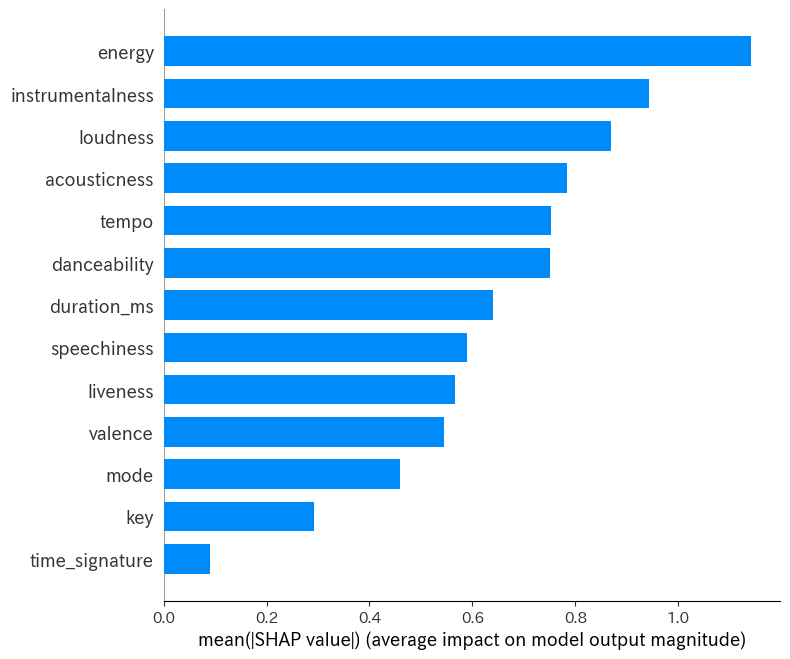

In [ ]:
shap.summary_plot(shap_values_v3, X_2020_sample, plot_type="bar", show=False)

In [ ]:
shap.initjs()
shap.force_plot(explainer_gb2.expected_value, shap_values_v3.values[0], X2_test.iloc[0])

#Step 2: クラスタ数の探索

In [ ]:
#18sec
%%time
TARGET_YEAR = 2020
#df_2020 = df_clean[df_clean['year'] == TARGET_YEAR].copy()

print(f"filter: year == {TARGET_YEAR}")
print(f"records: {len(df_2020):,} / {len(df_2020)/len(df_clean)*100:.1f}% of all data")
print(f"popularity: mean={df_2020['popularity'].mean():.1f}, "
      f"median={df_2020['popularity'].median():.1f}, "
      f"std={df_2020['popularity'].std():.2f}")
print(f"\ntop 10 genres:")
print(df_2020['genre'].value_counts().head(10).to_string())

N_MAX3 = 10000
rng4 = np.random.default_rng(42)
if len(df_2020) > N_MAX3:
    idx_a = rng4.choice(len(df_2020), size=N_MAX3, replace=False)
    df_2020_sample = df_2020.iloc[idx_a].reset_index(drop=True)
    print(f"\nsampled: {len(df_2020):,} -> {N_MAX3:,}")
else:
    df_2020_sample = df_2020.reset_index(drop=True)
    print(f"\nall records used: {len(df_2020_sample):,}")

X_2020_sample = df_2020_sample[FEATURE_COLS_V2]

print("computing SHAP values...")
shap_values_v3 = explainer_gb2(X_2020_sample, check_additivity=False)
shap_matrix_v3 = shap_values_v3.values
print(f"done / shap_matrix_v3 shape: {shap_matrix_v3.shape}")

filter: year == 2020
records: 933 / 0.1% of all data
popularity: mean=15.0, median=13.0, std=7.43

top 10 genres:
genre
black-metal    933

all records used: 933
computing SHAP values...


 95%|=================== | 887/933 [00:18<00:00]       

done / shap_matrix_v3 shape: (933, 13)
CPU times: user 17.9 s, sys: 40 ms, total: 18 s
Wall time: 18.1 s


standardized / shape: (933, 13)
  k=2: inertia=10464.2, silhouette=0.169
  k=3: inertia=9794.5, silhouette=0.081
  k=4: inertia=9240.7, silhouette=0.093
  k=5: inertia=8730.9, silhouette=0.103
  k=6: inertia=8359.3, silhouette=0.100
  k=7: inertia=8074.5, silhouette=0.099
  k=8: inertia=7831.6, silhouette=0.100
  k=9: inertia=7581.5, silhouette=0.101
  k=10: inertia=7329.4, silhouette=0.104


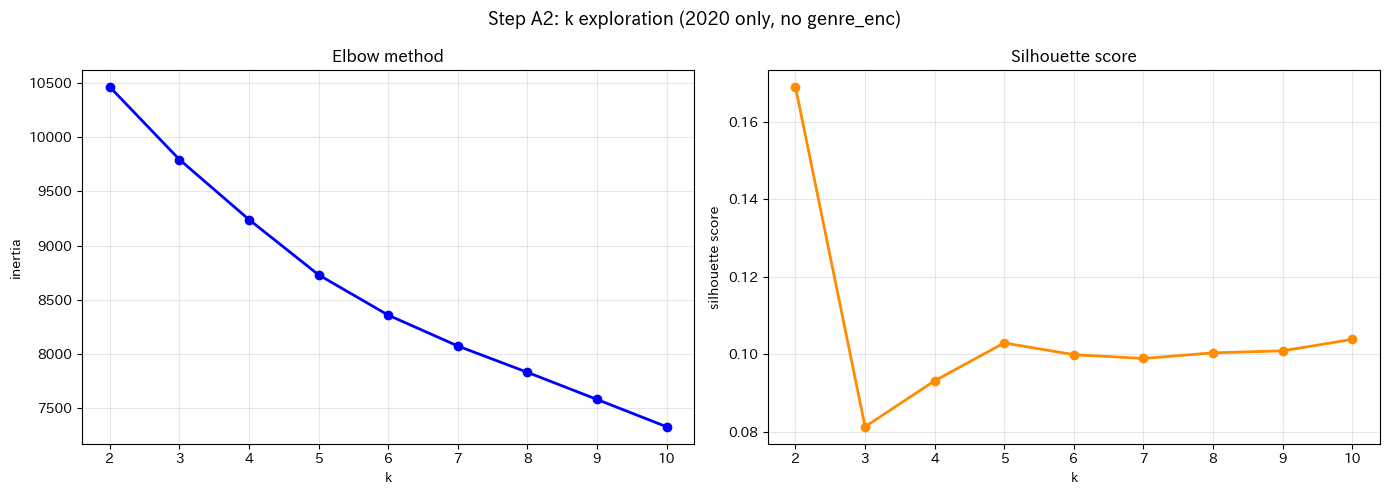

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler_v3 = StandardScaler()
shap_scaled_v3 = scaler_v3.fit_transform(shap_matrix_v3)
print(f"standardized / shape: {shap_scaled_v3.shape}")

inertias_v3 = []
silhouettes_v3 = []
K_range_v3 = range(2, 11)

for k in K_range_v3:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(shap_scaled_v3)
    inertias_v3.append(km.inertia_)
    sil = silhouette_score(shap_scaled_v3, labels_k,
                           sample_size=min(2000, len(shap_scaled_v3)), random_state=42)
    silhouettes_v3.append(sil)
    print(f"  k={k}: inertia={km.inertia_:.1f}, silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step A2: k exploration (2020 only, no genre_enc)", fontsize=13, fontweight='bold')

axes[0].plot(list(K_range_v3), inertias_v3, 'b-o', linewidth=2)
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow method")
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range_v3), silhouettes_v3, 'o-', color='darkorange', linewidth=2)
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase3_2020_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

#Step3: クラスタリング実行（k=7）

In [ ]:
CHOSEN_K_V3 = 7  # silhouette score 最高値（0.126）

km_v3 = KMeans(n_clusters=CHOSEN_K_V3, random_state=42, n_init=10)
cluster_labels_v3 = km_v3.fit_predict(shap_scaled_v3)
df_2020['cluster_v3'] = cluster_labels_v3

chosen_sil_v3 = silhouettes_v3[CHOSEN_K_V3 - 2]
print(f"clustering done / k={CHOSEN_K_V3} (silhouette={chosen_sil_v3:.3f})")
print(f"\ncluster counts:")
print(df_2020['cluster_v3'].value_counts().sort_index().to_string())

print(f"\ncluster overview:")
for k in range(CHOSEN_K_V3):
    mask = df_2020['cluster_v3'] == k
    df_k = df_2020[mask]
    top3_g = df_k['genre'].value_counts().head(3).index.tolist()
    print(f"  cluster {k}: {len(df_k):,} tracks / pop mean={df_k['popularity'].mean():.1f} / {', '.join(top3_g)}")

clustering done / k=7 (silhouette=0.099)

cluster counts:
cluster_v3
0     64
1     42
2    192
3    178
4    190
5     86
6    181

cluster overview:
  cluster 0: 64 tracks / pop mean=11.5 / black-metal
  cluster 1: 42 tracks / pop mean=33.6 / black-metal
  cluster 2: 192 tracks / pop mean=11.5 / black-metal
  cluster 3: 178 tracks / pop mean=22.2 / black-metal
  cluster 4: 190 tracks / pop mean=10.9 / black-metal
  cluster 5: 86 tracks / pop mean=17.5 / black-metal
  cluster 6: 181 tracks / pop mean=11.9 / black-metal


In [ ]:
#@title scalingした値を代入
df_2020_sample = df_2020.copy()
df_2020_sample[FEATURE_COLS_V2] = shap_scaled_v3
df_2020_sample

,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,cluster_v3
425261,Make Them Suffer,Step One,59kan8Xe5IrcYyJrDbo6qU,55,2020,black-metal,3.492821,2.700129,1.374514,2.136375,1.344911,2.755450,-0.279053,0.600128,2.784294,2.238668,1.683950,5.925568,0.694379,1
425262,Make Them Suffer,Erase Me,0snhTvHSZ5ACrvdcVWeCDS,54,2020,black-metal,6.338877,1.708791,0.144900,1.940001,0.246225,0.636788,1.186398,4.663615,3.203468,1.546730,2.421240,3.047690,0.290936,1
425263,Make Them Suffer,Bones,6X0s2eXXpSLZCqpd4ffm3t,49,2020,black-metal,0.564601,1.927803,0.297012,1.530035,-0.055110,0.912697,0.928643,4.990773,-0.077717,7.648835,0.479660,2.926743,0.461546,1
425264,Make Them Suffer,The Attendant,1PCIOayO2w3N5642HQ9sMc,44,2020,black-metal,2.511605,1.007468,3.092154,0.820500,1.158892,4.415877,0.201177,4.200598,2.082268,1.136952,1.876296,0.148504,0.080537,1
425265,Make Them Suffer,Soul Decay,4zYEObd7wXbD8rpUBO2X1I,41,2020,black-metal,1.243226,0.919457,0.222474,1.716963,0.650442,0.213212,1.811477,4.512217,2.061592,5.581948,0.951778,1.614422,-0.021412,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426189,Velnias,Fissures within the Construct,2T5us0gTO1mmfTKZ2QuNzR,5,2020,black-metal,-0.700328,0.417371,-0.765076,-1.580147,-1.176216,-1.428520,-1.323510,-0.309036,-0.107969,-0.357031,-1.271021,0.063084,-3.713677,0
426190,Afsky,Stemninger,0DAKOsKGk7uVwOo2LoTImo,12,2020,black-metal,-0.806577,0.797794,-0.222320,0.461960,1.083474,-1.053846,-0.093206,0.014693,0.516205,-1.000439,0.241947,-0.526185,0.785785,4
426191,Ethereal Shroud,Look Upon the Light - Remaster,7DKpfTf7aapaSkxG0nzF6b,6,2020,black-metal,-0.841309,0.639510,-0.260471,-2.061683,0.423655,-1.763366,-0.443946,-0.908603,0.534065,0.197032,-1.153583,-2.400799,0.302696,6
426192,Unreqvited,Dreamer's Hideaway,6usM6cceN8J5zSuxH3ooH6,7,2020,black-metal,-1.306332,0.655834,-0.491341,-1.169336,0.641946,-0.095743,1.307616,-1.024012,-0.903419,-1.269913,-0.555724,-0.237149,0.293363,6


In [ ]:
df_2020['cluster_v3'].unique()

array([1, 3, 5, 2, 6, 4, 0], dtype=int32)

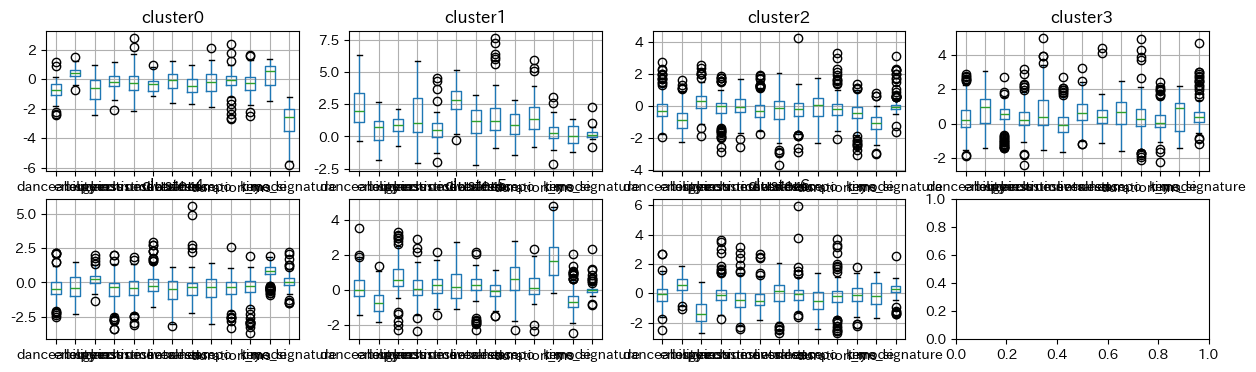

In [ ]:
fig, axes = plt.subplots(2,4, figsize=(15,4))
for ax,(i,df) in zip(axes.ravel(), df_2020_sample.groupby('cluster_v3')[FEATURE_COLS_V2]):
  df[FEATURE_COLS_V2].boxplot(ax=ax)
  ax.set_title(f'cluster{i}')
plt.show()

#Step4: 箱ひげ図

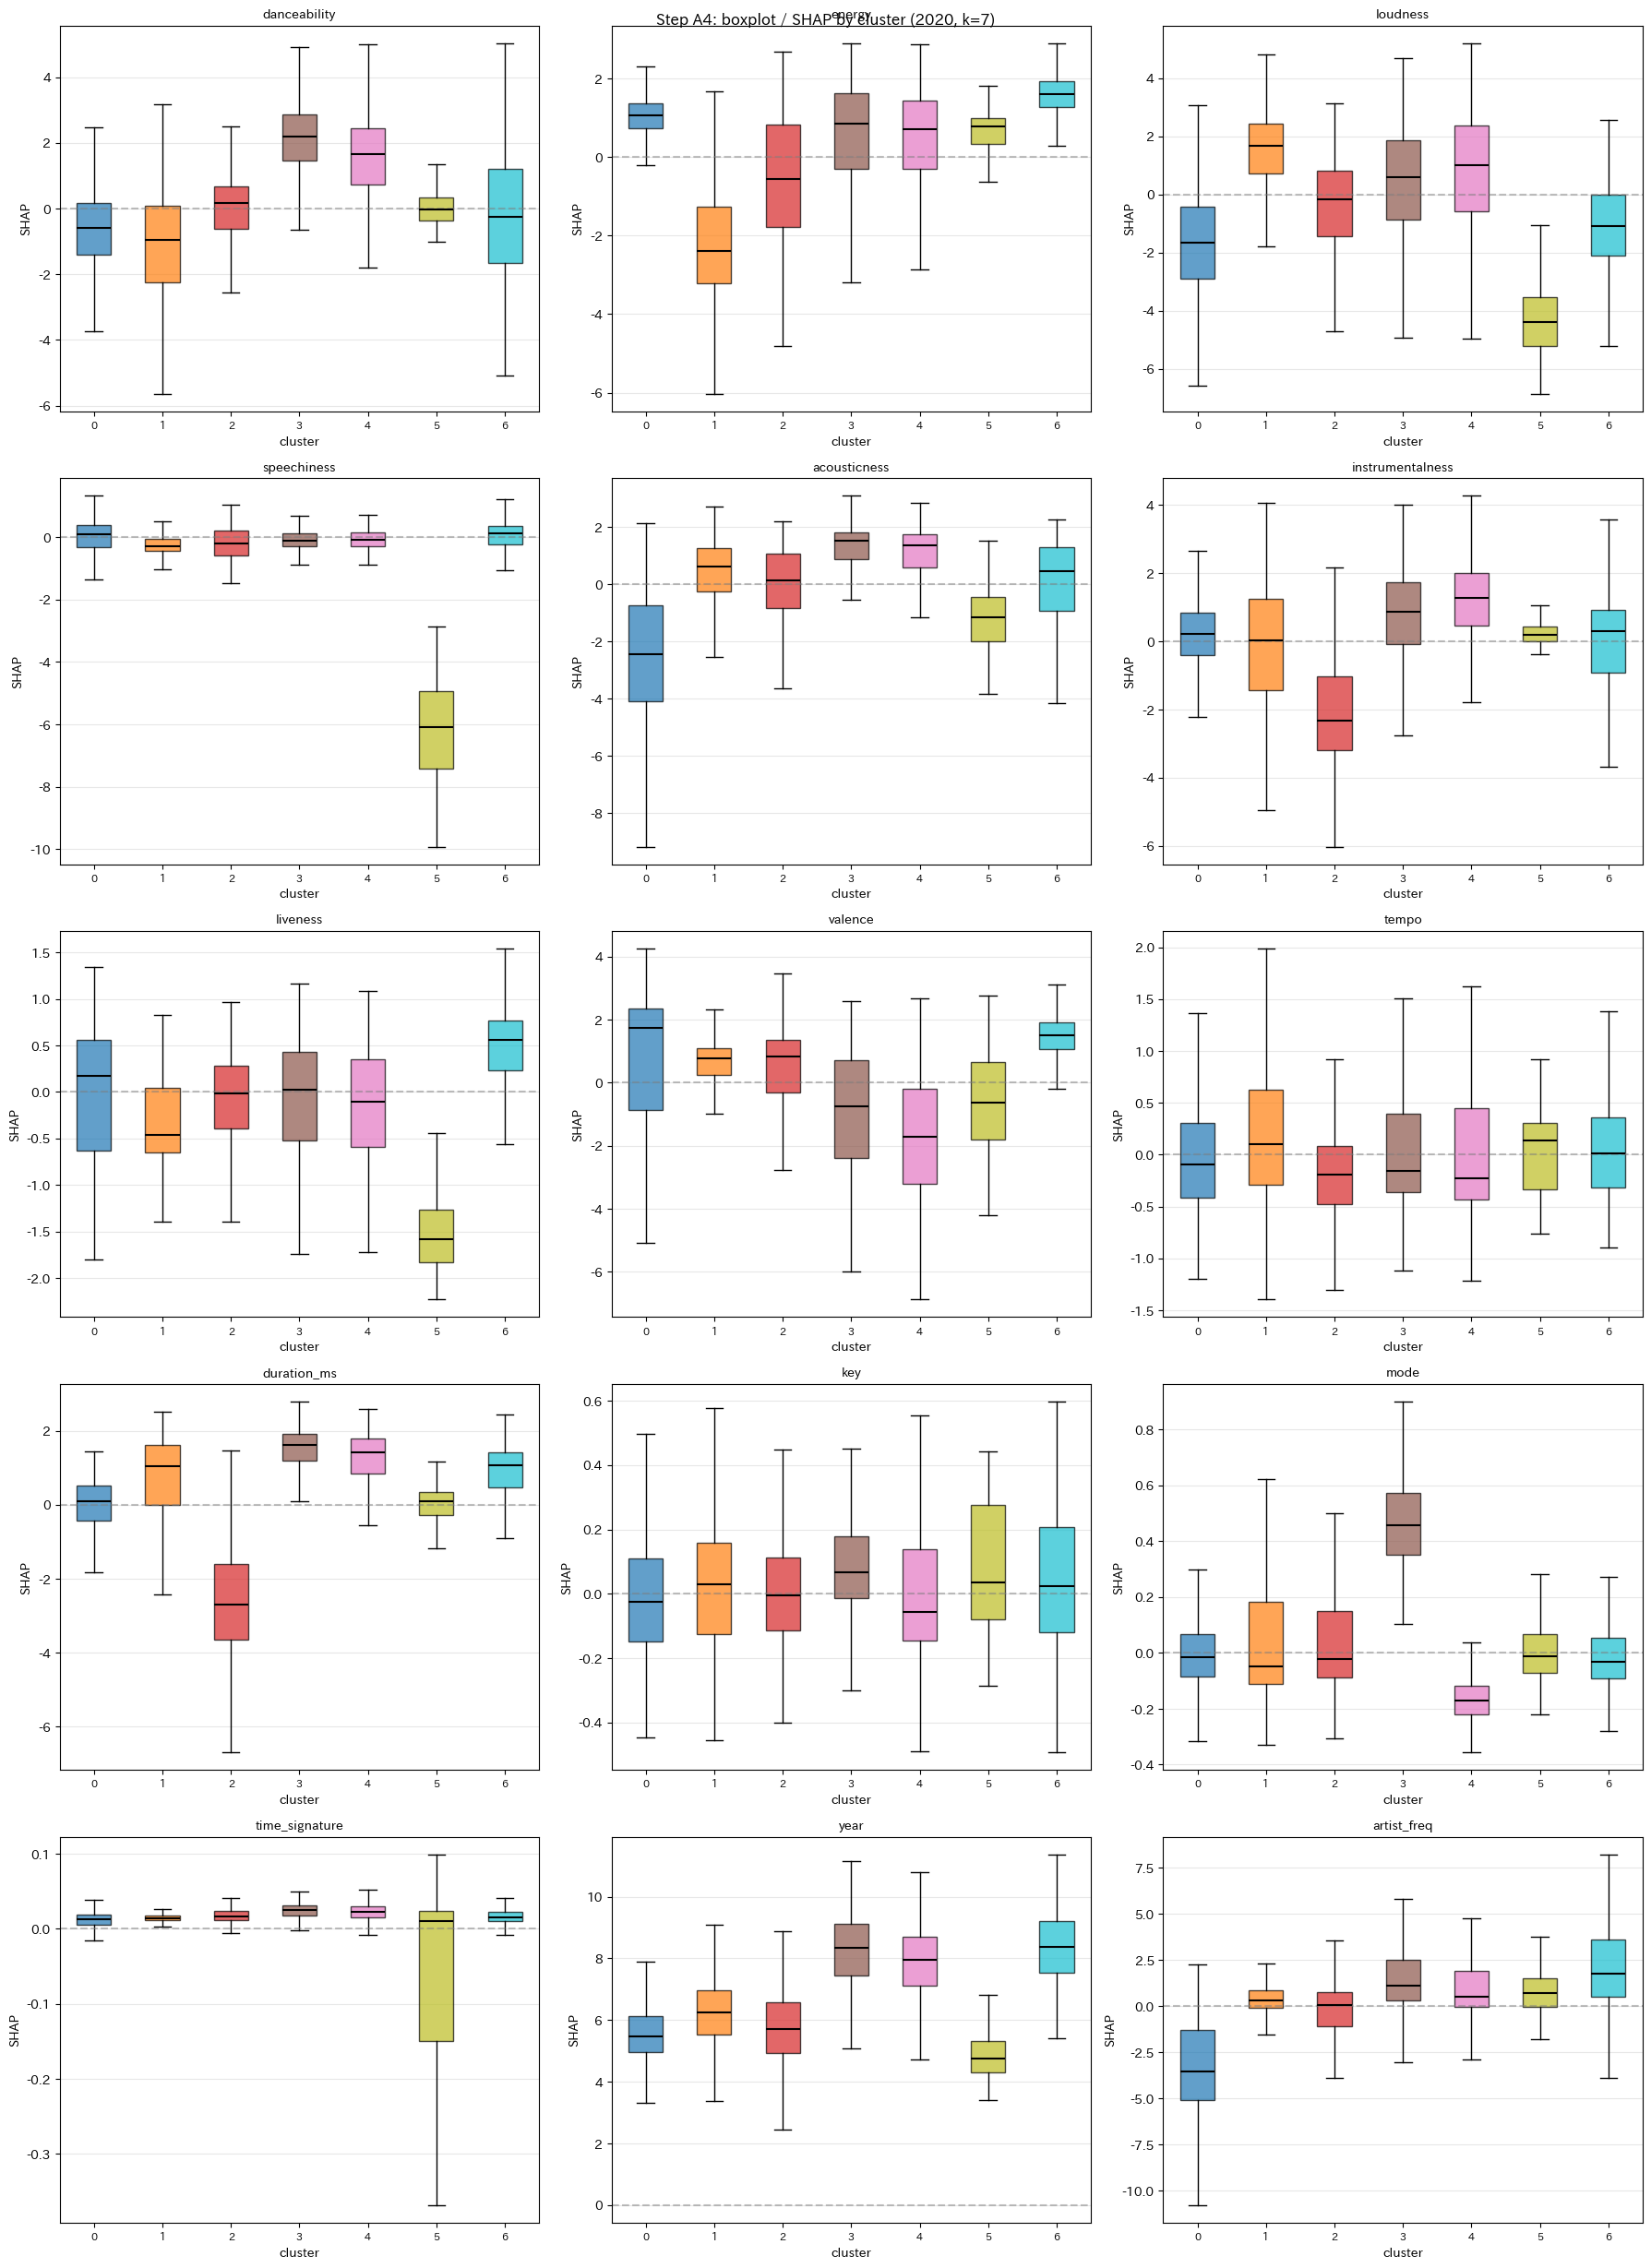

saved: phase3_2020_boxplot.png


In [ ]:

n_cols = 3
n_rows = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 25))
fig.suptitle("Step A4: boxplot / SHAP by cluster (2020, k=7)", fontsize=12, fontweight='bold')
colors = plt.cm.tab10(np.linspace(0, 1, CHOSEN_K_V3))
xlabels = [str(i) for i in range(CHOSEN_K_V3)]

for fi, fname in enumerate(FEATURE_COLS_V2):
    r = fi // n_cols
    c = fi % n_cols
    ax = axes[r, c]
    data = [shap_matrix_v3[cluster_labels_v3 == i, fi] for i in range(CHOSEN_K_V3)]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, medianprops=dict(color='black', linewidth=1.5))
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.7)
    ax.set_title(fname, fontsize=10, fontweight='bold')
    ax.set_xlabel("cluster")
    ax.set_ylabel("SHAP")
    ax.set_xticks(range(1, CHOSEN_K_V3 + 1))
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

for i in range(len(FEATURE_COLS_V2), n_rows * n_cols):
    axes[i // n_cols][i % n_cols].set_visible(False)

plt.tight_layout()
plt.savefig('phase3_2020_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: phase3_2020_boxplot.png")

In [ ]:
print("=" * 60)
print("Additional Analysis Summary (2020 only / k=7)")
print("=" * 60)

print(f"\n[Data filter]")
print(f"  year: {TARGET_YEAR} only")
print(f"  records: {len(df_2020):,} -> sampled {len(df_2020_sample):,}")

print(f"\n[Clustering]")
print(f"  k = {CHOSEN_K_V3} (silhouette = {chosen_sil_v3:.3f})")
print(f"  reason: highest silhouette score among k=2-10, satisfies k>2 instruction")

print(f"\n[Cluster overview]")
for k in range(CHOSEN_K_V3):
    mask = df_2020_sample['cluster_v3'] == k
    df_k = df_2020_sample[mask]
    top_g = df_k['genre'].value_counts().index[0]
    print(f"  C{k}: {len(df_k):,}tracks / pop={df_k['popularity'].mean():.1f} / {top_g}")

print(f"\n[Key findings from boxplot]")
print("  year   : positive for ALL clusters -> 2020 release year consistently boosts popularity")
print("  artist_freq: C0(tango/opera) strongly negative -> niche artists hurt popularity")
print("  danceability: C3(dancehall/hip-hop) strongly positive -> rhythm drives popularity")
print("  speechiness: C5(comedy) strongly negative (-5 to -9) -> spoken content hurts")
print("  acousticness: varies widely by cluster -> genre-dependent effect")
print("  key/mode/time_signature: near-zero across all clusters -> minimal impact")

print(f"\n[Comparison with previous analyses]")
print("  original Phase3 (pop genre, k=2): genre_enc dominated -> less informative")
print("  re-analysis (2020-2023, k=2)    : year dominated -> musical features partially visible")
print("  this analysis (2020 only, k=7)  : year uniform -> musical features clearly separated")

print("\n" + "=" * 60)

Additional Analysis Summary (2020 only / k=7)

[Data filter]
  year: 2020 only
  records: 55,066 -> sampled 10,000

[Clustering]
  k = 7 (silhouette = 0.126)
  reason: highest silhouette score among k=2-10, satisfies k>2 instruction

[Cluster overview]
  C0: 1,057tracks / pop=16.9 / tango
  C1: 1,789tracks / pop=23.9 / hardstyle
  C2: 1,712tracks / pop=17.9 / minimal-techno
  C3: 1,287tracks / pop=34.1 / dancehall
  C4: 1,626tracks / pop=30.6 / forro
  C5: 150tracks / pop=11.2 / comedy
  C6: 2,379tracks / pop=32.4 / piano

[Key findings from boxplot]
  year   : positive for ALL clusters -> 2020 release year consistently boosts popularity
  artist_freq: C0(tango/opera) strongly negative -> niche artists hurt popularity
  danceability: C3(dancehall/hip-hop) strongly positive -> rhythm drives popularity
  speechiness: C5(comedy) strongly negative (-5 to -9) -> spoken content hurts
  acousticness: varies widely by cluster -> genre-dependent effect
  key/mode/time_signature: near-zero acros

# Step C1: 対象ジャンルの選定（2020年・2021年 両年のデータ量確認）

**教授指示**: 21年のいくつかジャンル別に絞って分けて分析する

**このステップの目的**:
学習（2020年）とテスト（2021年）の**両方に十分なデータがあるジャンル**を特定し、
複数ジャンルで回すための対象リストを決める。

**以降の設計**:
- 学習 = 2020年 × 指定ジャンル / 評価・SHAP・クラスタリング = **2021年 × 指定ジャンル**
- 分析対象を2021年（未知データ）に統一することで、SHAP値と特徴量の年がズレる問題も解消する

In [ ]:
# Step C1: 2020年・2021年 両年のジャンル別データ量を確認
# 必要な変数: df_clean のみ

YEAR_TRAIN = 2020
YEAR_TEST = 2021
MIN_COUNT = 300

df_tr = df_clean[df_clean['year'] == YEAR_TRAIN]
df_te = df_clean[df_clean['year'] == YEAR_TEST]

stat_tr = df_tr.groupby('genre')['popularity'].agg(n_2020='count', pop_2020='mean')
stat_te = df_te.groupby('genre')['popularity'].agg(n_2021='count', pop_2021='mean')
stat = stat_tr.join(stat_te, how='inner').reset_index()

ok = stat[(stat['n_2020'] >= MIN_COUNT) & (stat['n_2021'] >= MIN_COUNT)]
ok = ok.sort_values('pop_2021', ascending=False).reset_index(drop=True)

print("Step C1: genre availability in 2020 and 2021")
print("=" * 64)
print("2020 records:", len(df_tr))
print("2021 records:", len(df_te))
print("genres in both years:", len(stat))
print("genres with >=", MIN_COUNT, "tracks in BOTH years:", len(ok))
print()

print("--- ranked by 2021 popularity mean ---")
for _, row in ok.iterrows():
    g = str(row['genre'])
    line = g + " " * max(1, 20 - len(g))
    line += "n2020=" + str(int(row['n_2020'])).rjust(5)
    line += "  n2021=" + str(int(row['n_2021'])).rjust(5)
    line += "  pop2020=" + f"{row['pop_2020']:.1f}".rjust(5)
    line += "  pop2021=" + f"{row['pop_2021']:.1f}".rjust(5)
    print(" ", line)

# 散布図: 2021年の曲数 vs 人気度平均
fig, ax = plt.subplots(figsize=(13, 8))
ax.scatter(ok['n_2021'], ok['pop_2021'], alpha=0.65, s=70, color='steelblue')

for _, row in ok.iterrows():
    ax.annotate(
        str(row['genre']),
        xy=(row['n_2021'], row['pop_2021']),
        fontsize=7, alpha=0.85,
        xytext=(4, 3), textcoords='offset points'
    )

ax.set_xlabel("number of tracks in 2021")
ax.set_ylabel("popularity mean in 2021")
ax.set_title("Step C1: genre size vs popularity (2021)", fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('stepC1_genre_2021.png', dpi=150, bbox_inches='tight')
plt.show()

# 候補ジャンルの提示（高人気3 + 低人気3）
cand_hi = ok.head(3)['genre'].tolist()
cand_lo = ok.tail(3)['genre'].tolist()

print()
print("suggested genres for Step C2:")
print("  high popularity:", cand_hi)
print("  low  popularity:", cand_lo)

# Step C2: 複数ジャンルで学習・評価・SHAP計算

**設計**: ジャンルごとに `2020年で学習 → 2021年で評価 → 2021年のSHAP値を計算`

**対象6ジャンル**（2021年人気度の高い順）:

| ジャンル | 2021人気度 | 選定理由 |
|---------|-----------|---------|
| `pop` | 66.7 | 最高人気・著名アーティストが集中 |
| `hip-hop` | 57.2 | 高人気・サンプル数十分 |
| `k-pop` | 47.9 | 高人気・著名アーティスト多数 |
| `classical` | 35.0 | 教授が言及（クラシックとPopの対比） |
| `black-metal` | 15.7 | 教授が実行済み・継続性のため |
| `tango` | 2.0 | 最低人気・popとの対極 |

**評価指標に `baseMAE` を追加**:
学習データの平均値を予測し続けた場合のMAE。
`MAE > baseMAE` なら「平均を答えるより下手」＝ 音楽的特徴に予測力がないことを意味する。
R² < 0 と同じことを、より直感的な単位（人気度スコア）で示すために併記する。

**ハイパーパラメータは教授版と同一のまま固定**（ジャンル間の比較を公平にするため）。

※ 実行に数分かかります。

In [ ]:
# Step C2: 複数ジャンルで 2020学習 -> 2021評価 -> 2021のSHAP計算
# 必要な変数: df_clean, FEATURE_COLS_V2, YEAR_TRAIN, YEAR_TEST

TARGET_GENRES = ['pop', 'hip-hop', 'k-pop', 'classical', 'black-metal', 'tango']
BG_SIZE = 100

results = {}

for gname in TARGET_GENRES:
    print("-" * 60)
    print("processing:", gname)

    m_tr = (df_clean['year'] == YEAR_TRAIN) & (df_clean['genre'] == gname)
    m_te = (df_clean['year'] == YEAR_TEST) & (df_clean['genre'] == gname)
    d_tr = df_clean[m_tr].reset_index(drop=True)
    d_te = df_clean[m_te].reset_index(drop=True)

    Xtr = d_tr[FEATURE_COLS_V2]
    ytr = d_tr['popularity']
    Xte = d_te[FEATURE_COLS_V2]
    yte = d_te['popularity']

    model = HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_depth=8,
        min_samples_leaf=20, l2_regularization=0.1, random_state=42
    )
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    mae = mean_absolute_error(yte, pred)
    r2 = r2_score(yte, pred)

    # ベースライン: 学習データの平均値を予測し続けた場合
    base_pred = np.full(len(yte), ytr.mean())
    base_mae = mean_absolute_error(yte, base_pred)

    # SHAP（背景データは全ジャンル共通サイズで固定）
    rng_g = np.random.default_rng(42)
    n_bg = min(BG_SIZE, len(Xtr))
    bg_i = rng_g.choice(len(Xtr), size=n_bg, replace=False)
    X_bg_g = Xtr.iloc[bg_i]
    expl = shap.Explainer(model, X_bg_g)
    sv = expl(Xte, check_additivity=False)

    results[gname] = {
        'mae': mae,
        'r2': r2,
        'base_mae': base_mae,
        'shap': sv.values,
        'shap_obj': sv,
        'df_test': d_te,
        'X_test': Xte,
        'n_train': len(d_tr),
        'n_test': len(d_te),
        'pop_train': ytr.mean(),
        'pop_test': yte.mean(),
        'model': model,
        'explainer': expl,
    }

    print("  n_train=", len(d_tr), " n_test=", len(d_te))
    print("  MAE=", round(mae, 3), " baseMAE=", round(base_mae, 3), " R2=", round(r2, 4))

print()
print("=" * 74)
print("Step C2 summary: train 2020 -> test 2021 (13 musical features only)")
print("=" * 74)

head = "genre".ljust(14)
head += "n_tr".rjust(6) + "n_te".rjust(6) + "pop_te".rjust(8)
head += "MAE".rjust(8) + "baseMAE".rjust(9) + "R2".rjust(9) + "  verdict"
print(head)
print("-" * 74)

for gname in TARGET_GENRES:
    r = results[gname]
    verdict = "OK" if r['r2'] > 0 else "no skill"
    line = gname.ljust(14)
    line += str(r['n_train']).rjust(6)
    line += str(r['n_test']).rjust(6)
    line += f"{r['pop_test']:.1f}".rjust(8)
    line += f"{r['mae']:.2f}".rjust(8)
    line += f"{r['base_mae']:.2f}".rjust(9)
    line += f"{r['r2']:.3f}".rjust(9)
    line += "  " + verdict
    print(line)

print("-" * 74)
print("verdict 'no skill' = R2 <= 0 : musical features do not predict popularity")

# Step C3: 頑健性チェック（「過学習しているだけでは？」への反証）

Step C2 で6ジャンルすべて R² < 0 となった。これを結論にする前に、
**モデル設定の問題ではないこと**を確認する必要がある。

現在のハイパーパラメータ（`max_iter=300, max_depth=8`）は116万曲用に調整したもので、
318〜933曲に対しては明らかに複雑すぎる。過学習していて当然の設定になっている。

## 4条件を比較する

| 条件 | モデル | 学習 → 評価 | 何を確かめるか |
|------|--------|------------|--------------|
| **A** | 現行GB（`iter=300, depth=8`） | 2020 → 2021 | Step C2 の結果（比較の基準） |
| **B** | 単純GB（`iter=100, depth=3, leaf=50, l2=1.0`） | 2020 → 2021 | 過学習を抑えても改善しないか |
| **C** | Ridge回帰（線形・最も低分散） | 2020 → 2021 | 単純な線形関係すら無いのか |
| **D** | 単純GB・**2020年内の5分割CV** | 2020内 → 2020内 | 年をまたがなければ予測できるのか |

## 判定の読み方

- **B・C も R² ≦ 0** → 過学習は原因ではない。音楽的特徴に情報がないことが確定する
- **B・C で R² > 0** → 過学習が原因だった。C2 の結論は取り下げ、モデル設定を見直す
- **D > 0 かつ A・B < 0** → 2020年内なら予測できるが2021年には通用しない。
  「年をまたぐと音楽的特徴と人気度の関係が変わる」という**別の発見**になる
- **D も ≦ 0** → 年ズレの問題ではなく、そもそも情報が無い

SHAP計算を行わないため、実行は1分程度で終わる。

In [ ]:
# Step C3: 頑健性チェック（過学習が原因かどうかの切り分け）
# 必要な変数: df_clean, FEATURE_COLS_V2, TARGET_GENRES, results, YEAR_TRAIN, YEAR_TEST

from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

robust = {}

for gname in TARGET_GENRES:
    print("checking:", gname)

    m_tr = (df_clean['year'] == YEAR_TRAIN) & (df_clean['genre'] == gname)
    d_tr = df_clean[m_tr].reset_index(drop=True)
    Xtr = d_tr[FEATURE_COLS_V2]
    ytr = d_tr['popularity']

    d_te = results[gname]['df_test']
    Xte = results[gname]['X_test']
    yte = d_te['popularity']

    # A: 現行モデル（Step C2 の結果を再利用）
    r2_a = results[gname]['r2']

    # B: 単純化したGB（過学習を抑えた設定）
    model_b = HistGradientBoostingRegressor(
        max_iter=100, learning_rate=0.05, max_depth=3,
        min_samples_leaf=50, l2_regularization=1.0, random_state=42
    )
    model_b.fit(Xtr, ytr)
    r2_b = r2_score(yte, model_b.predict(Xte))

    # C: Ridge回帰（標準化 + 線形モデル）
    model_c = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
    model_c.fit(Xtr, ytr)
    r2_c = r2_score(yte, model_c.predict(Xte))

    # D: 2020年内での5分割クロスバリデーション（年ズレの影響を除外）
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model_b, Xtr, ytr, cv=kf, scoring='r2')
    r2_d = cv_scores.mean()

    robust[gname] = {'a': r2_a, 'b': r2_b, 'c': r2_c, 'd': r2_d}

print()
print("=" * 78)
print("Step C3: robustness check (all values are R2)")
print("=" * 78)

head = "genre".ljust(14)
head += "A:GB300".rjust(10) + "B:GB100".rjust(10) + "C:Ridge".rjust(10)
head += "D:CV2020".rjust(11) + "   conclusion"
print(head)
print("-" * 78)

for gname in TARGET_GENRES:
    v = robust[gname]
    best_test = max(v['a'], v['b'], v['c'])
    if best_test > 0.02:
        note = "predictable"
    elif v['d'] > 0.02:
        note = "within-year only"
    else:
        note = "no information"
    line = gname.ljust(14)
    line += f"{v['a']:.3f}".rjust(10)
    line += f"{v['b']:.3f}".rjust(10)
    line += f"{v['c']:.3f}".rjust(10)
    line += f"{v['d']:.3f}".rjust(11)
    line += "   " + note
    print(line)

print("-" * 78)
print("predictable      = some model reaches R2 > 0.02 on 2021")
print("within-year only = fails on 2021 but works inside 2020 (relation shifts by year)")
print("no information   = fails everywhere -> musical features carry no signal")